In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
np.random.seed(42)

def generate_ct_volume(shape=(128, 256, 256)):
    volume = np.full(shape, -1000, dtype=np.float32)
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    cz, cy, cx = shape[0]//2, shape[1]//2, shape[2]//2
    body = ((z-cz)/50)**2 + ((y-cy)/90)**2 + ((x-cx)/70)**2 < 1
    volume[body] = 50
    spine = ((y-cy)/8)**2 + ((x-cx)/8)**2 < 1
    volume[spine & body] = 700
    for i, zpos in enumerate(range(30, 100, 10)):
        angle = i * 0.3
        for t in np.linspace(0, np.pi, 60):
            rx = int(cx + 55 * np.cos(t) * np.cos(angle))
            ry = int(cy + 55 * np.sin(t))
            rz = int(zpos + 5 * np.sin(t * 2))
            if 0 <= rx < shape[2] and 0 <= ry < shape[1] and 0 <= rz < shape[0]:
                volume[max(0,rz-2):rz+2,
                       max(0,ry-2):ry+2,
                       max(0,rx-2):rx+2] = 700
    lung_l = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx-25))/25)**2 < 1
    lung_r = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx+25))/25)**2 < 1
    volume[lung_l & body] = -500
    volume[lung_r & body] = -500
    liver = ((z-(cz+15))/25)**2 + ((y-(cy+15))/30)**2 + ((x-(cx+20))/28)**2 < 1
    volume[liver & body] = 60
    kidney_l = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx-30))/10)**2 < 1
    kidney_r = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx+30))/10)**2 < 1
    volume[kidney_l & body] = 30
    volume[kidney_r & body] = 30
    aorta = ((y-(cy+5))/6)**2 + ((x-(cx-8))/6)**2 < 1
    volume[aorta & body] = 40
    noise = np.random.normal(0, 15, shape).astype(np.float32)
    volume += noise
    volume = ndimage.gaussian_filter(volume, sigma=0.8)
    return volume

def segment_organs(volume):
    masks = {}
    cz = volume.shape[0]//2
    cy = volume.shape[1]//2
    cx = volume.shape[2]//2
    bone_mask = volume > 350
    bone_mask = ndimage.binary_closing(bone_mask, iterations=2)
    bone_mask = ndimage.binary_fill_holes(bone_mask)
    masks['bone'] = bone_mask
    lung_mask = (volume > -700) & (volume < -300)
    labeled, n = ndimage.label(lung_mask)
    sizes = ndimage.sum(lung_mask, labeled, range(1, n+1))
    large = [i+1 for i, s in enumerate(sizes) if s > 500]
    lung_mask = np.isin(labeled, large)
    lung_mask = ndimage.binary_closing(lung_mask, iterations=3)
    lung_mask = ndimage.binary_fill_holes(lung_mask)
    masks['lungs'] = lung_mask
    liver_mask = (volume > 45) & (volume < 80)
    liver_mask = ndimage.binary_opening(liver_mask, iterations=2)
    liver_mask = ndimage.binary_closing(liver_mask, iterations=4)
    liver_mask = ndimage.binary_fill_holes(liver_mask)
    labeled, n = ndimage.label(liver_mask)
    if n > 0:
        sizes = ndimage.sum(liver_mask, labeled, range(1, n+1))
        largest = np.argmax(sizes) + 1
        liver_mask = labeled == largest
    masks['liver'] = liver_mask
    kidney_mask = (volume > 20) & (volume < 45)
    kidney_mask = ndimage.binary_opening(kidney_mask, iterations=2)
    kidney_mask = ndimage.binary_closing(kidney_mask, iterations=3)
    labeled, n = ndimage.label(kidney_mask)
    if n > 0:
        sizes = ndimage.sum(kidney_mask, labeled, range(1, n+1))
        top2 = np.argsort(sizes)[-2:] + 1
        kidney_mask = np.isin(labeled, top2)
    masks['kidneys'] = kidney_mask
    return masks

volume = generate_ct_volume()
masks = segment_organs(volume)
print("Volume and masks ready")
print(f"Organs: {list(masks.keys())}")

Volume and masks ready
Organs: ['bone', 'lungs', 'liver', 'kidneys']


In [3]:
def mask_to_mesh(mask, step_size=2):
    """Convert binary mask to 3D surface mesh using Marching Cubes."""
    # smooth mask before meshing for cleaner surfaces
    smoothed = ndimage.gaussian_filter(mask.astype(float), sigma=1.5)
    
    # marching cubes — finds isosurface at level 0.5
    verts, faces, normals, values = measure.marching_cubes(
        smoothed, level=0.5, step_size=step_size
    )
    return verts, faces, normals

print("Applying Marching Cubes to all organ masks...")
print("(This may take 1-2 minutes)\n")

meshes = {}
organ_config = {
    'bone':    {'step': 1, 'color': '#FFFFF0'},
    'lungs':   {'step': 2, 'color': '#6EB5FF'},
    'liver':   {'step': 2, 'color': '#CC4444'},
    'kidneys': {'step': 1, 'color': '#E07820'},
}

for organ, config in organ_config.items():
    print(f"  Processing {organ}...", end=" ")
    verts, faces, normals = mask_to_mesh(
        masks[organ], step_size=config['step'])
    meshes[organ] = {
        'verts': verts,
        'faces': faces,
        'normals': normals,
        'color': config['color']
    }
    print(f"done — {len(verts):,} vertices, {len(faces):,} faces")

print("\nAll meshes generated successfully")

Applying Marching Cubes to all organ masks...
(This may take 1-2 minutes)

  Processing bone... done — 15,908 vertices, 31,784 faces
  Processing lungs... done — 10,166 vertices, 20,308 faces
  Processing liver... done — 33,648 vertices, 67,332 faces
  Processing kidneys... done — 6,240 vertices, 12,472 faces

All meshes generated successfully


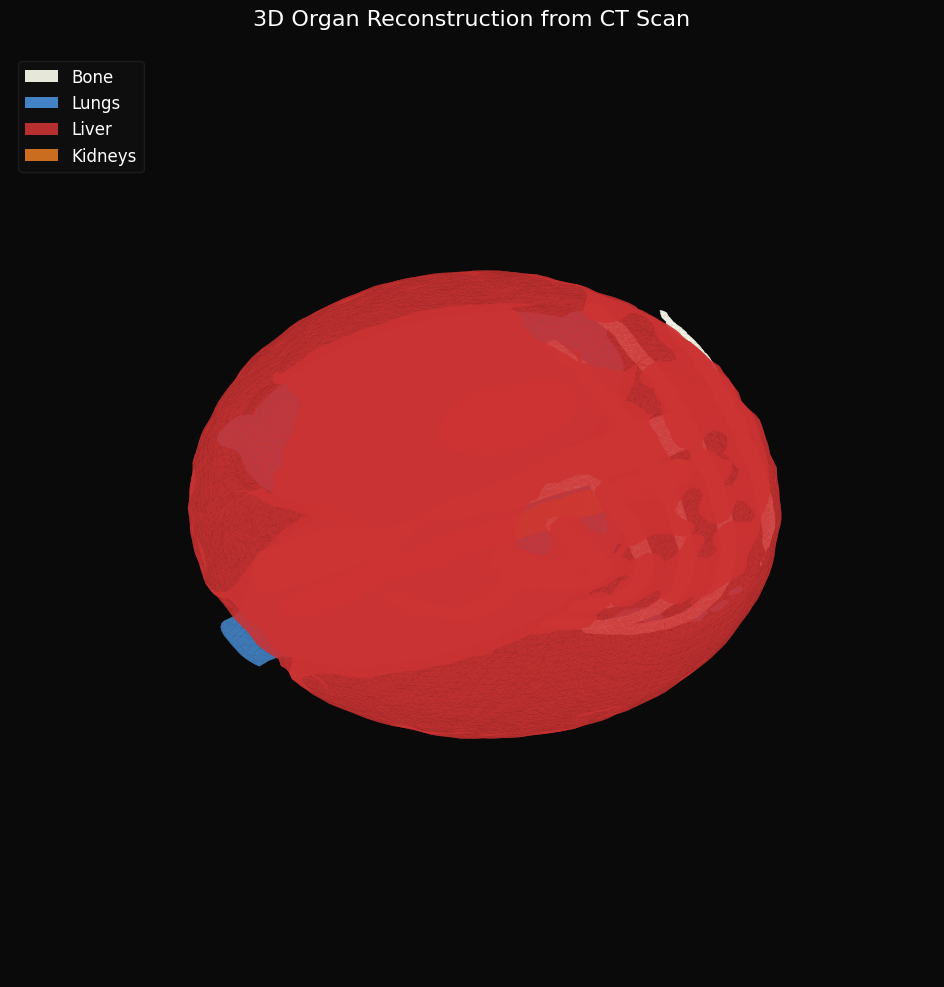

Saved to outputs/3d_reconstruction.png


In [4]:
def plot_3d_organs(meshes, figsize=(16, 12), azim=45, elev=20):
    fig = plt.figure(figsize=figsize, facecolor='#0a0a0a')
    ax = fig.add_subplot(111, projection='3d',
                         facecolor='#0a0a0a')

    organ_styles = {
        'bone':    {'color': '#FFFFF0', 'alpha': 0.85, 'label': 'Bone'},
        'lungs':   {'color': '#4A90D9', 'alpha': 0.6,  'label': 'Lungs'},
        'liver':   {'color': '#CC3333', 'alpha': 0.75, 'label': 'Liver'},
        'kidneys': {'color': '#E07820', 'alpha': 0.85, 'label': 'Kidneys'},
    }

    for organ, style in organ_styles.items():
        if organ not in meshes:
            continue
        verts = meshes[organ]['verts']
        faces = meshes[organ]['faces']
        mesh = Poly3DCollection(verts[faces],
                                alpha=style['alpha'],
                                linewidth=0)
        mesh.set_facecolor(style['color'])
        mesh.set_edgecolor('none')
        ax.add_collection3d(mesh)

    # set axis limits
    all_verts = np.vstack([m['verts'] for m in meshes.values()])
    ax.set_xlim(all_verts[:,0].min(), all_verts[:,0].max())
    ax.set_ylim(all_verts[:,1].min(), all_verts[:,1].max())
    ax.set_zlim(all_verts[:,2].min(), all_verts[:,2].max())

    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()

    # legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=s['color'], label=s['label'], alpha=0.9)
        for s in organ_styles.values()
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              fancybox=True, framealpha=0.3,
              labelcolor='white', facecolor='#1a1a1a',
              edgecolor='#444444', fontsize=12)

    ax.set_title('3D Organ Reconstruction from CT Scan',
                 color='white', fontsize=16, pad=20)

    return fig, ax

fig, ax = plot_3d_organs(meshes)
plt.savefig('../outputs/3d_reconstruction.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a0a')
plt.show()
print("Saved to outputs/3d_reconstruction.png")

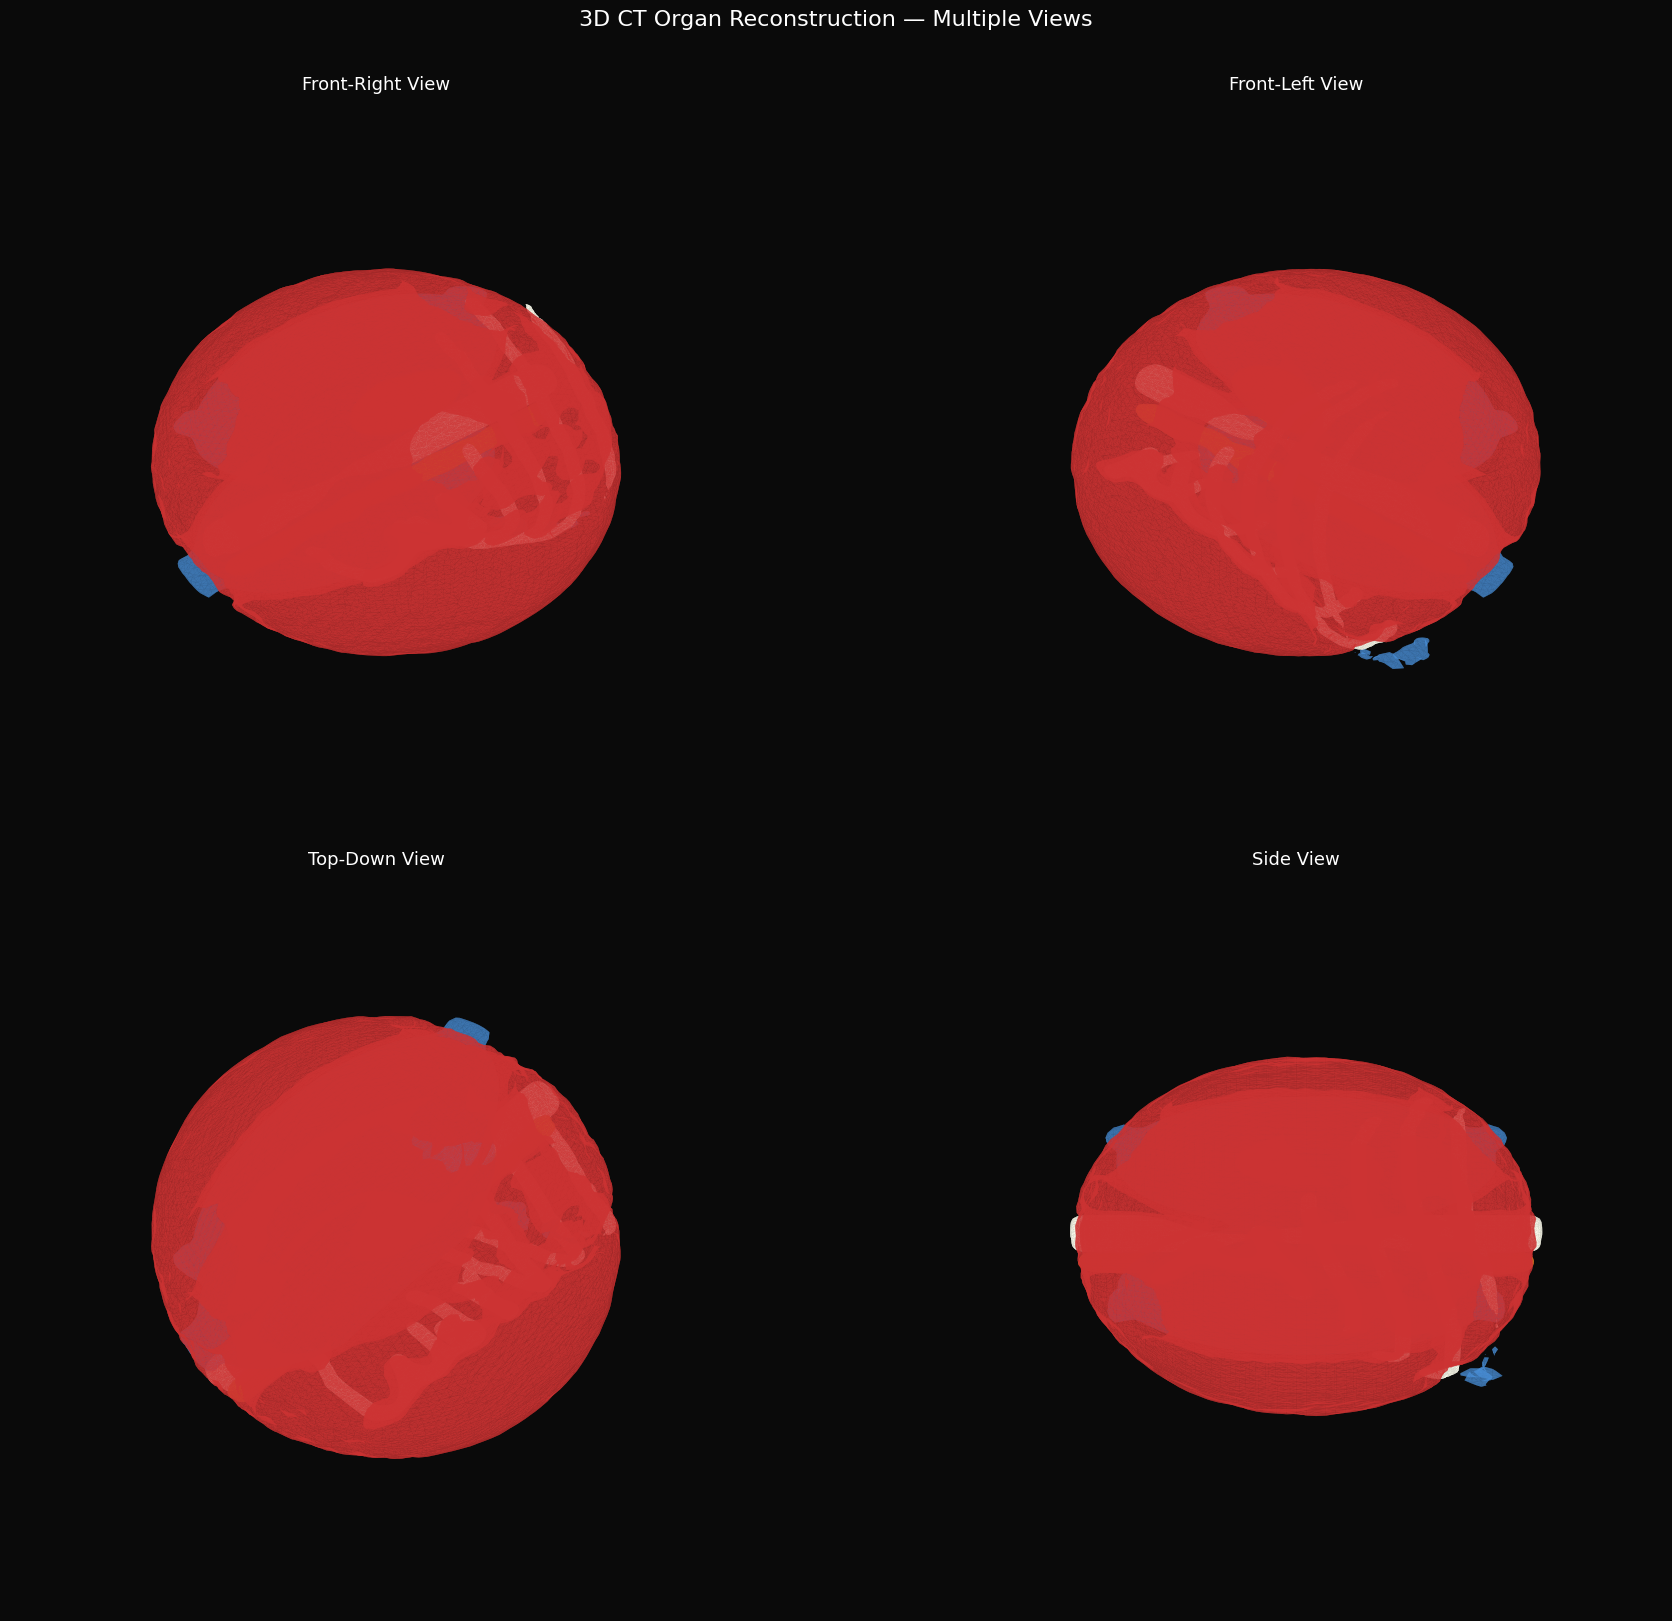

Saved to outputs/3d_multiview.png


In [5]:
fig = plt.figure(figsize=(20, 16), facecolor='#0a0a0a')

views = [
    (30,  45,  "Front-Right View"),
    (30,  135, "Front-Left View"),
    (60,  45,  "Top-Down View"),
    (10,  90,  "Side View"),
]

organ_styles = {
    'bone':    {'color': '#FFFFF0', 'alpha': 0.85},
    'lungs':   {'color': '#4A90D9', 'alpha': 0.55},
    'liver':   {'color': '#CC3333', 'alpha': 0.75},
    'kidneys': {'color': '#E07820', 'alpha': 0.85},
}

all_verts = np.vstack([m['verts'] for m in meshes.values()])

for idx, (elev, azim, title) in enumerate(views):
    ax = fig.add_subplot(2, 2, idx+1,
                         projection='3d', facecolor='#0a0a0a')

    for organ, style in organ_styles.items():
        verts = meshes[organ]['verts']
        faces = meshes[organ]['faces']
        mesh = Poly3DCollection(verts[faces],
                                alpha=style['alpha'],
                                linewidth=0)
        mesh.set_facecolor(style['color'])
        mesh.set_edgecolor('none')
        ax.add_collection3d(mesh)

    ax.set_xlim(all_verts[:,0].min(), all_verts[:,0].max())
    ax.set_ylim(all_verts[:,1].min(), all_verts[:,1].max())
    ax.set_zlim(all_verts[:,2].min(), all_verts[:,2].max())
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(title, color='white', fontsize=13, pad=10)

plt.suptitle('3D CT Organ Reconstruction — Multiple Views',
             color='white', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/3d_multiview.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0a0a')
plt.show()
print("Saved to outputs/3d_multiview.png")